In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf

from pymargins import Margins

raw = sm.datasets.anes96.load_pandas().data.copy()
# 7-point PID coded 0..6. Keep covariates compact for the demo.
df = raw[["PID", "TVnews", "selfLR", "age", "educ", "income"]].dropna().copy()
df["PID"] = df["PID"].astype(int)
print(df.describe().round(2))
print("\nOutcome distribution:")
print(df["PID"].value_counts().sort_index())

          PID  TVnews  selfLR     age    educ  income
count  944.00  944.00  944.00  944.00  944.00  944.00
mean     2.84    3.73    4.33   47.04    4.57   16.33
std      2.27    2.68    1.44   16.42    1.60    5.97
min      0.00    0.00    1.00   19.00    1.00    1.00
25%      1.00    1.00    3.00   34.00    3.00   14.00
50%      2.00    3.00    4.00   44.00    4.00   17.00
75%      5.00    7.00    6.00   58.00    6.00   21.00
max      6.00    7.00    7.00   91.00    7.00   24.00

Outcome distribution:
PID
0    200
1    180
2    108
3     37
4     94
5    150
6    175
Name: count, dtype: int64


In [2]:
fit = smf.mnlogit(
    "PID ~ TVnews + selfLR + age + educ + income",
    data=df,
).fit(disp=False)
print(fit.summary().tables[1])

     PID=1       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2758      0.620     -0.445      0.656      -1.491       0.939
TVnews        -0.0994      0.043     -2.290      0.022      -0.185      -0.014
selfLR         0.2900      0.094      3.076      0.002       0.105       0.475
age           -0.0186      0.007     -2.619      0.009      -0.033      -0.005
educ           0.0808      0.073      1.100      0.271      -0.063       0.225
income         0.0041      0.018      0.233      0.815      -0.030       0.039
------------------------------------------------------------------------------
     PID=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -2.4823      0.750     -3.311      0.001      -3.952      -1.013
TVnews        -0.0368      0.050     -0.731      0.4

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:626: UserWarning: Delta-method curvature κ=0.533 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


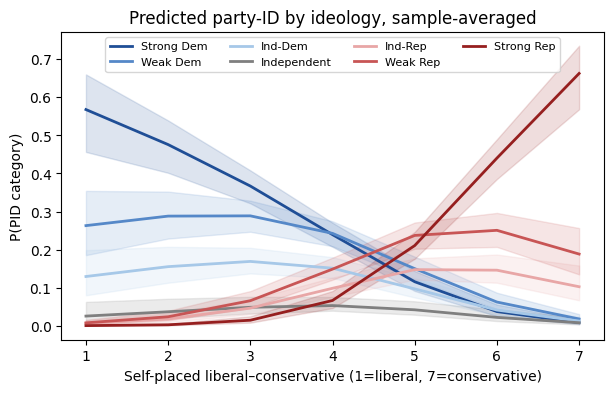

In [3]:
import matplotlib.pyplot as plt

m = Margins.linear_scale(fit, at="overall")
lr_grid = list(range(1, 8))  # selfLR scale 1..7
res = m.predict(atexog={"selfLR": lr_grid})

est = np.asarray(res.estimate)        # (n_lr, n_outcomes)
ci = np.asarray(res.conf_int())       # (2, n_lr, n_outcomes)
n_lr, n_out = est.shape

pid_labels = [
    "Strong Dem", "Weak Dem", "Ind-Dem",
    "Independent",
    "Ind-Rep", "Weak Rep", "Strong Rep",
]
# Blue = Democrat, red = Republican, grey = independent — standard US
# political color convention.
colors = ["#1f4e96", "#5588c8", "#a6c8e8",
          "#7f7f7f",
          "#e8a6a6", "#c85555", "#961f1f"]

fig, ax = plt.subplots(figsize=(7, 4))
for j in range(n_out):
    ax.plot(lr_grid, est[:, j], color=colors[j], label=pid_labels[j], lw=2)
    ax.fill_between(
        lr_grid, ci[0, :, j], ci[1, :, j], alpha=0.15, color=colors[j]
    )
ax.set(xlabel="Self-placed liberal–conservative (1=liberal, 7=conservative)",
       ylabel="P(PID category)",
       title="Predicted party-ID by ideology, sample-averaged")
ax.legend(loc="upper center", ncol=4, fontsize=8)

In [4]:
ame_lr = m.dydx("selfLR")
print(ame_lr.summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:716: UserWarning: Delta-method curvature κ=0.729 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


             Margins Result (simulation, level=0.95)             
            estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-----------------------------------------------------------------
selfLR (0)   -0.0967   0.0079    -0.0967  0.000  -0.1114, -0.0805
selfLR (1)   -0.0513   0.0072    -0.0513  0.000  -0.0664, -0.0385
selfLR (2)   -0.0274   0.0056    -0.0274  0.000  -0.0387, -0.0169
selfLR (3)   -0.0052   0.0034    -0.0052  0.062   -0.0135, 0.0003
selfLR (4)    0.0198   0.0054     0.0198  0.000    0.0097, 0.0309
selfLR (5)    0.0363   0.0070     0.0363  0.000    0.0233, 0.0508
selfLR (6)    0.1243   0.0084     0.1243  0.000    0.1084, 0.1415

n = 944
WARNING — Fallback triggered: kappa=0.729>threshold=0.3
κ: max=0.729


In [5]:
print(m.dydx("educ").summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:716: UserWarning: Delta-method curvature κ=0.407 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


            Margins Result (simulation, level=0.95)            
          estimate  std err  statistic  P>|z|  [95% Conf. Int.]
---------------------------------------------------------------
educ (0)   -0.0197   0.0081    -0.0197  0.011  -0.0350, -0.0037
educ (1)   -0.0054   0.0084    -0.0054  0.500   -0.0223, 0.0108
educ (2)    0.0065   0.0069     0.0065  0.372   -0.0075, 0.0198
educ (3)   -0.0056   0.0048    -0.0056  0.221   -0.0155, 0.0036
educ (4)    0.0016   0.0066     0.0016  0.796   -0.0112, 0.0147
educ (5)    0.0051   0.0078     0.0051  0.554   -0.0110, 0.0195
educ (6)    0.0174   0.0074     0.0174  0.015    0.0030, 0.0324

n = 944
WARNING — Fallback triggered: kappa=0.407>threshold=0.3
κ: max=0.407


In [6]:
import jax.numpy as jnp

def dem_minus_rep(p):
    # p: (n_scenarios, n_outcomes=7) — per-scenario category probabilities.
    # Returns one gap per scenario.
    dem = p[..., 0:3].sum(axis=-1)   # strong Dem, weak Dem, ind-Dem
    rep = p[..., 4:7].sum(axis=-1)   # ind-Rep, weak Rep, strong Rep
    return dem - rep

# One scenario per ideology level; compose collapses the outcome axis.
scenarios = [{"atexog": {"selfLR": v}, "label": f"selfLR={v}"}
             for v in lr_grid]
res_diff = m.evaluate(scenarios=scenarios, compose=dem_minus_rep)
print(res_diff.summary())

/home/hunter/Workspace/pymargins/pymargins/margins/_session.py:990: UserWarning: Delta-method curvature κ=0.336 exceeds threshold (0.3); falling back to simulation.
  result_data = run_inference(


              Margins Result (simulation, level=0.95)              
              estimate  std err  statistic  P>|z|  [95% Conf. Int.]
-------------------------------------------------------------------
selfLR=1 (0)    0.9461   0.0177     0.9461  0.000    0.8992, 0.9668
selfLR=1 (1)    0.8752   0.0243     0.8752  0.000    0.8141, 0.9094
selfLR=1 (2)    0.6979   0.0342     0.6979  0.000    0.6184, 0.7508
selfLR=1 (3)    0.3196   0.0388     0.3196  0.000    0.2369, 0.3870
selfLR=1 (4)   -0.2329   0.0410    -0.2329  0.000  -0.3103, -0.1497
selfLR=1 (5)   -0.6961   0.0365    -0.6961  0.000  -0.7562, -0.6124
selfLR=1 (6)   -0.9153   0.0198    -0.9153  0.000  -0.9430, -0.8651

n = 944
WARNING — Fallback triggered: kappa=0.336>threshold=0.3
κ: max=0.336
